# Neural network from sklearn

see: https://scikit-learn.org/dev/modules/neural_networks_supervised.html

Author: Aleksander Filip Żarnecki (University of Warsaw)

### (0) Import libraries 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier

# For random number generation

from scipy.stats import norm
from scipy.stats import expon

### (1) Define generation procedure for "signal" and "background" distributions

In [2]:
# Normal distribution in (R,Phi) with correlation for signal

def mysig(Nmc,pos,sig,corr=0.0):

    data = np.ones(shape=(Nmc,2))
    
    phi = 0.5*np.arcsin(corr)

    g = np.random.normal(size=(2,Nmc))

    r  = pos[0] + sig[0]*(g[0]*np.cos(phi) + g[1]*np.sin(phi))
    th = pos[1] + sig[1]*(g[0]*np.sin(phi) + g[1]*np.cos(phi))

    data[:,0] = r * np.cos(th)
    data[:,1] = r * np.sin(th)
    
    return data

# Exponential distribution with correlation for background

def mybg(Nmc,pos,sig,corr=0.0):

    data = np.ones(shape=(Nmc,2))
    
    phi = 0.5*np.arcsin(corr)

    g = np.random.normal(size=(2,Nmc))

    r1_tab = g[0]*np.cos(phi) + g[1]*np.sin(phi)
    r2_tab = g[0]*np.sin(phi) + g[1]*np.cos(phi)

# Convert correlated gaussian variables r1 & r2 
# to correlated exponential variables, based on survival function

    s1_tab = norm.sf(r1_tab)
    s2_tab = norm.sf(r2_tab)
    
    data[:,0] = pos[0] + sig[0]*expon.isf(s1_tab)
    data[:,1] = pos[1] + sig[1]*expon.isf(s2_tab)
    
    return data

### (2) Generating training and test data

In [3]:
# Sample size

Ntrain = 1000
Ntest = 1000

# Two hypothesis:

# H1: Background - exponential

h1 = np.array([-2.0,-2.0])
sig1 = np.array([2.0,2.0])
corr1 = 0.0

# H2: Signal - normal in (R,phi)

h2 = np.array([1.,0.78])
sig2 = np.array([0.25,1.0])
corr2 = 0.97

# Fraction of signal (h2) hypothesis

fh2 = 0.5

fh1 = 1 - fh2

# Generate train sample 
# ---------------------

h1train = mybg(Ntrain,h1,sig1,corr1)
h2train = mysig(Ntrain,h2,sig2,corr2)

# Uniform distributed numbers

rtrain = np.random.uniform(size=Ntrain)

# Mix of two hypothesis

y_train = rtrain < fh2

y2_train = np.resize(np.repeat(y_train,2),(Ntrain,2))

X_train = y2_train * h2train + (1 - y2_train)*h1train

print("Train data defined, size: ",y_train.size)

# Generate test sample 
# --------------------

h1test = mybg(Ntest,h1,sig1,corr1)
h2test = mysig(Ntest,h2,sig2,corr2)

# Uniform distributed numbers

rtest = np.random.uniform(size=Ntest)

# Mix of two hypothesis

y_test = rtest < fh2

y2_test = np.resize(np.repeat(y_test,2),(Ntest,2))

X_test = y2_test * h2test + (1 - y2_test)*h1test

print("Test data defined, size: ",y_test.size)

# Rescale category from {0,1} to {-1,1}

y_train = 2*y_train - 1
y_test = 2*y_test - 1

Train data defined, size:  1000
Test data defined, size:  1000


### (3) sklear neural network classifier

In [76]:
# Allow for one, two or three hidden layers

hl1 = 20
hl2 = 10
hl3 = 5

# Code network configuration

hlayers = hl1
ltit = str(hl1)
lfil = str(hl1)

if hl2 > 0:
    hlayers = (hl1,hl2)
    ltit = str(hl1)+'+'+str(hl2)
    lfil = str(hl1)+'_'+str(hl2)
    
if hl3 > 0:
    hlayers = (hl1,hl2,hl3)
    ltit = str(hl1)+'+'+str(hl2)+'+'+str(hl3)
    lfil = str(hl1)+'_'+str(hl2)+'_'+str(hl3)
    
# Network initialization and training

clf = MLPClassifier(hidden_layer_sizes=hlayers, activation='tanh', max_iter=2000)

clf.fit(X_train, y_train)

# Network classification results

y_train_pred = clf.predict(X_train)

print("Number of mislabeled training points out of a total %d points : %d"
        % (X_train.shape[0], (y_train != y_train_pred).sum()))

y_test_pred  = clf.predict(X_test)

print("Number of mislabeled test points out of a total %d points : %d"
        % (X_test.shape[0], (y_test != y_test_pred).sum()))

Number of mislabeled training points out of a total 1000 points : 22
Number of mislabeled test points out of a total 1000 points : 36


### (4) Plot results

In [77]:
# 2D grid for decision histogram (as background)

Xmin = -2.0
Xmax = 4.0
Nbin = 120
dX = (Xmax-Xmin)/Nbin

Xrange = np.linspace(Xmin+0.5*dX,Xmax-0.5*dX,Nbin)

X1grid, X2grid = np.meshgrid(Xrange,Xrange)

# Prepare an array of test points

Xgrid = np.empty((Nbin*Nbin,2))
Xgrid[:,0] = X1grid.reshape(Nbin*Nbin)
Xgrid[:,1] = X2grid.reshape(Nbin*Nbin)

yval = clf.predict(Xgrid)

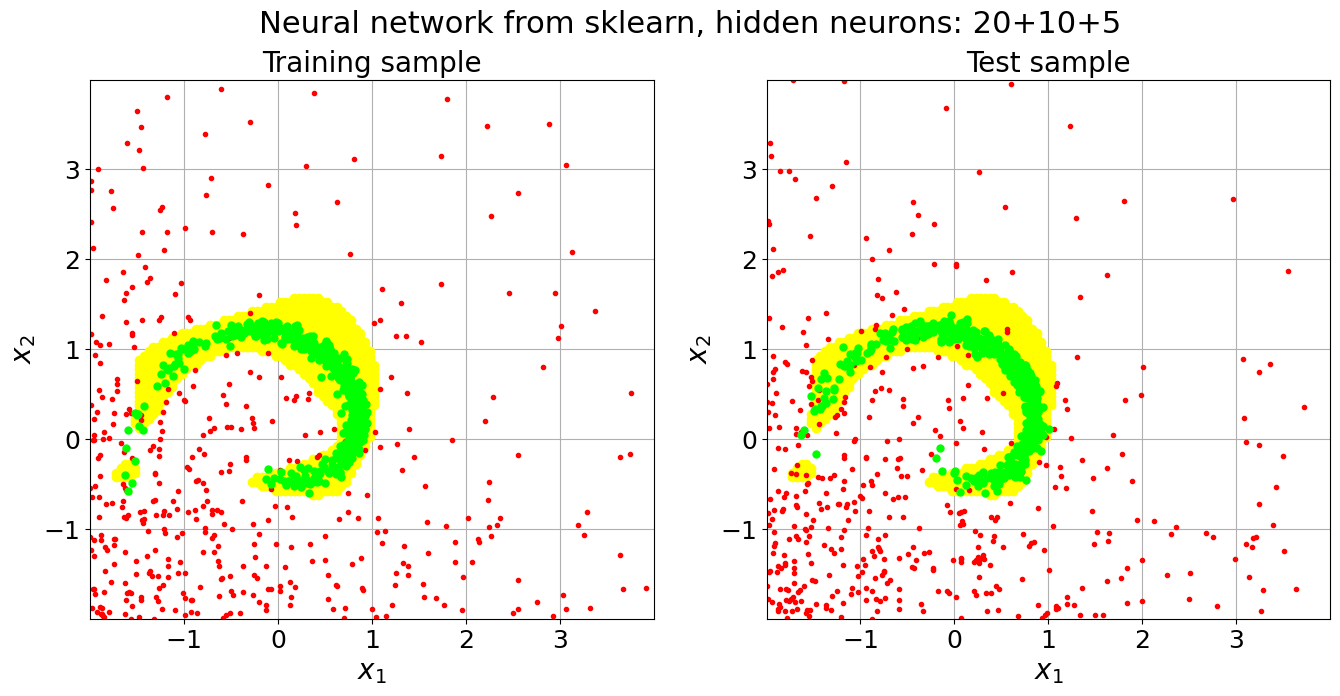

In [78]:
# Create result graph

Xmin = -1.999
Xmax = 3.999

plt.subplots(1,2,figsize=(16, 7))

plt.suptitle("Neural network from sklearn, hidden neurons: "+ltit,fontsize=22)

# Train sample

plt.subplot(121)

# Decision pattern as background

plt.plot(Xgrid[:,0][yval==1],Xgrid[:,1][yval==1],'o',color='yellow')
plt.xlim([Xmin,Xmax])
plt.ylim([Xmin,Xmax])

# Training points in two categories

plt.plot(X_train[:,0][y_train==-1],X_train[:,1][y_train==-1],'o',color='red',ms=3)
plt.plot(X_train[:,0][y_train==1],X_train[:,1][y_train==1],'o',color='lime',ms=5)

plt.title("Training sample",size=20)
plt.xlabel('$x_1$',size=20)
plt.ylabel('$x_2$',size=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(which='major', axis='both')

# Test sample

plt.subplot(122)

# Decision pattern as background

plt.plot(Xgrid[:,0][yval==1],Xgrid[:,1][yval==1],'o',color='yellow')
plt.xlim([Xmin,Xmax])
plt.ylim([Xmin,Xmax])

# Test points in two categories

plt.plot(X_test[:,0][y_test==-1],X_test[:,1][y_test==-1],'o',color='red',ms=3)
plt.plot(X_test[:,0][y_test==1],X_test[:,1][y_test==1],'o',color='lime',ms=5)

plt.title("Test sample",size=20)
plt.xlabel('$x_1$',size=20)
plt.ylabel('$x_2$',size=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(which='major', axis='both')


fname = '13_NNsk_'+lfil+'.png'

plt.savefig(fname)

plt.show()

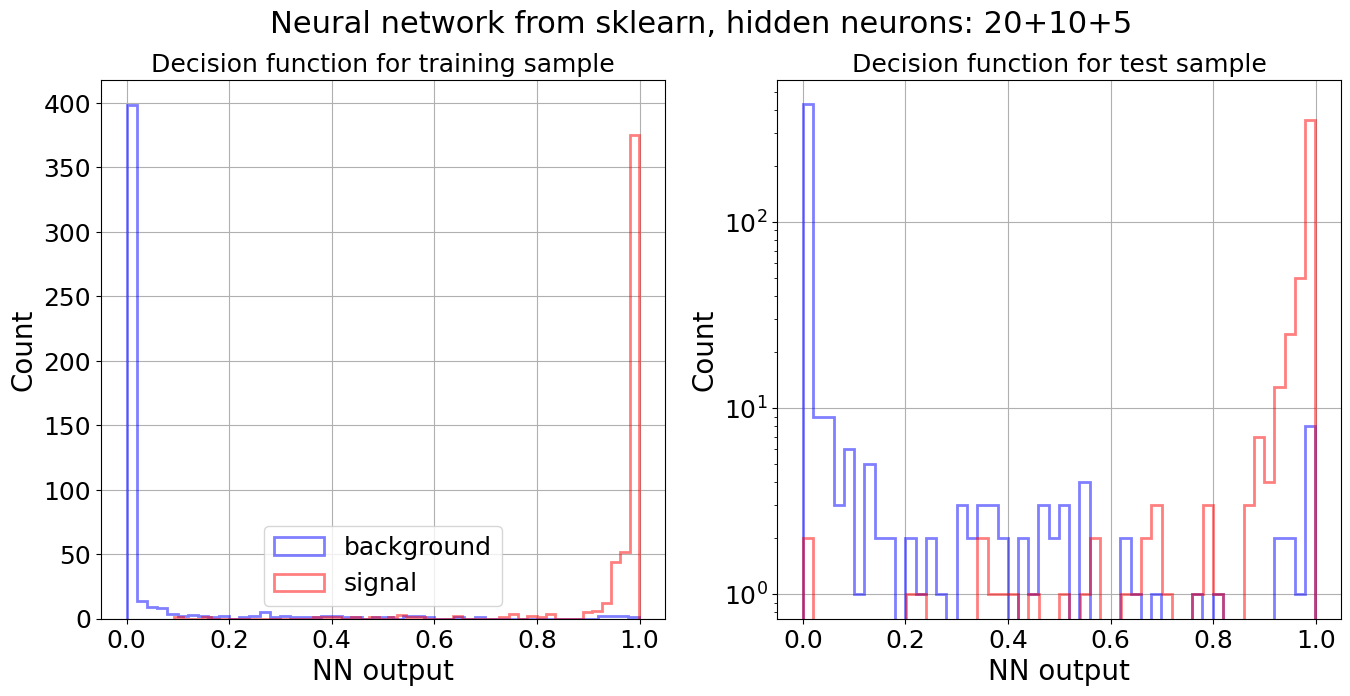

In [79]:
# Distribution of the NN output value

dec_train = clf.predict_proba(X_train)[:, 1]
dec_test = clf.predict_proba(X_test)[:, 1]


# From tutorial plot_histogram()
#clf, X_train, y_train)

plt.subplots(1,2,figsize=(16, 7))

plt.suptitle("Neural network from sklearn, hidden neurons: "+ltit,fontsize=22)

# Train sample

plt.subplot(121)

plt.hist(dec_train[y_train == -1.0], bins=50, log=False, histtype='step', linewidth=2, color="b", alpha=0.5, label='background')
plt.hist(dec_train[y_train == 1.0], bins=50, log=False, histtype='step', linewidth=2, color="r", alpha=0.5, label='signal')
plt.legend(fontsize=18);

plt.xlabel('NN output',size=20)
plt.ylabel('Count',size=20)
plt.title("Decision function for training sample",size=18)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(which='major', axis='both')


plt.subplot(122)

plt.hist(dec_test[y_test == -1.0], bins=50, log=True, histtype='step', linewidth=2,  color="b", alpha=0.5, label='background')
plt.hist(dec_test[y_test == 1.0], bins=50,  log=True, histtype='step', linewidth=2,  color="r", alpha=0.5, label='signal')

plt.xlabel('NN output',size=20)
plt.ylabel('Count',size=20)
plt.title("Decision function for test sample",size=18)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(which='major', axis='both')

fname = '13_NNsk_'+lfil+'_dec.png'

plt.savefig(fname)

plt.show()

